In [1]:
import inspect
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

$$\frac{\mathrm{d}N}{\mathrm{d}t} = k$$
$$\frac{\mathrm{d}N}{\mathrm{d}t} = k N$$
$$\frac{\mathrm{d}N}{\mathrm{d}t} = k N \left(1 - \frac{N}{K}\right)$$
$$\frac{\mathrm{d}N}{\mathrm{d}t} = k N \left(1 - \frac{N}{K}\right) - c$$
$$\frac{\mathrm{d}N}{\mathrm{d}t} = k N \left(1 - \frac{N}{K}\right)\left(1 - \frac{c}{N}\right)$$
$$\frac{\mathrm{d}N}{\mathrm{d}t} = k N \left[1 - \left(\frac{N}{K}\right)^\nu\right]$$
$$\frac{\mathrm{d}N}{\mathrm{d}t} = k N \log \left(\frac{K}{N}\right)$$

In [2]:
def linear(t, N, k):
    return k

In [3]:
def exponetial(t, N, k):
    return k * N

In [4]:
def logistic(t, N, k, K):
    return k * N * (1. - N / K)

In [5]:
def logistic_with_harvesting(t, N, k, K, c):
    return k * N * (1. - N / K) - c

In [6]:
def logistic_sparse(t, N, k, K, c):
    return k * N * (1. - N / K) * (1. - c / N)

In [7]:
def generalized_logistic(t, N, k, K, nu):
    return k * N * (1. - np.power(N / K, nu))

In [8]:
def gompertz(t, N, k, K):
    return k * N * np.log(K / N)

In [9]:
t = np.linspace(0., 10., 200)

In [10]:
models = [
    linear,
    exponetial,
    logistic,
    logistic_with_harvesting,
    logistic_sparse,
    generalized_logistic,
    gompertz,
]

In [11]:
y0 = 1e4

In [12]:
constants = {
    "k": 1.,
    "K": 1e5,
    "c": 1e3,
    "nu": 1.1,
}

In [13]:
solutions = []
for model in models:
    signature = inspect.signature(model)
    parameters = list(signature.parameters.keys())[2:]
    solution = integrate.solve_ivp(model, [t[0], t[-1]], y0=[y0], t_eval=t, args=[constants[parameter] for parameter in parameters])
    print(model.__name__, solution.message)
    solutions.append(solution)

linear The solver successfully reached the end of the integration interval.
exponetial The solver successfully reached the end of the integration interval.
logistic The solver successfully reached the end of the integration interval.
logistic_with_harvesting The solver successfully reached the end of the integration interval.
logistic_sparse The solver successfully reached the end of the integration interval.
generalized_logistic The solver successfully reached the end of the integration interval.
gompertz The solver successfully reached the end of the integration interval.


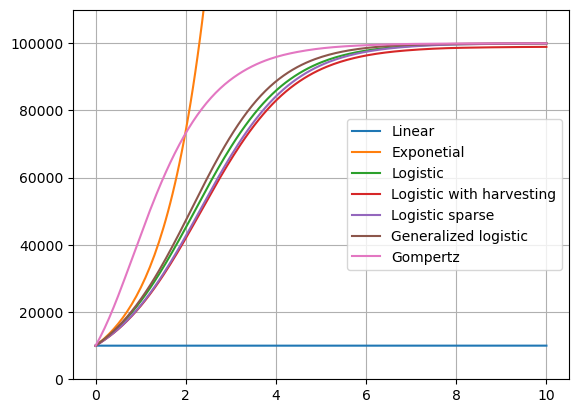

In [15]:
fig, axe = plt.subplots()
for solution, model in zip(solutions, models):
    axe.plot(t, solution.y.T)
axe.set_ylim([0., 1.1e5])
axe.legend([model.__name__.replace("_", " ").capitalize() for model in models])
axe.grid()